### **🚗 Car Price Prediction with Machine Learning**

**Objective**
Build a regression model that predicts the **selling price of a used car**
based on features such as brand, age, mileage, fuel type, and transmission.

**Tech Stack**
`Python` · `pandas` · `scikit-learn` · `xgboost` · `matplotlib` · `seaborn` · `plotly` · `Jupyter Notebook`

**Workflow**
1. **Data Loading** — read the raw dataset
2. **Data Cleaning** — nulls, duplicates, inconsistent categorical text
3. **Feature Engineering** — car age, brand extraction
4. **Exploratory Data Analysis (EDA)** — distributions & relationships
5. **Encoding** — Ordinal / Binary / One-Hot, chosen per feature's nature
6. **Feature Correlation Heatmap**
7. **Train/Test Split & Scaling**
8. **Model Training** — Linear Regression, Random Forest, XGBoost
9. **Model Evaluation** — MAE, RMSE, R² score
10. **Feature Importance** — for the best-performing model

#### **Dataset**

| Column | Description |
|---|---|
| `name` | Car model name (includes brand) |
| `year` | Year of manufacture |
| `selling_price` | Selling price of the car (**target variable**) |
| `km_driven` | Total kilometers driven |
| `fuel` | Fuel type (Petrol/Diesel/CNG/LPG/Electric) |
| `seller_type` | Individual / Dealer / Trustmark Dealer |
| `transmission` | Manual / Automatic |
| `owner` | Ownership history (First/Second/Third owner, etc.) |
| `mileage` | Fuel efficiency (kmpl or km/kg) |
| `engine` | Engine displacement (CC) |
| `max_power` | Maximum power output (bhp) |
| `torque` | Torque details (free text) |
| `seats` | Number of seats |


### **1. Import Required Libraries**

In [57]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Utilities
from datetime import datetime
import re

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Consistent plot styling
sns.set_theme(style="whitegrid")

### **2. Load the Dataset**

In [58]:
from pathlib import Path

DATA_PATH = Path(r"D:\PROJECTS\Intership\Data_Science\OIBSIP\DataScience-Task3-CarPricePrediction\Car Price Dataset.csv")
car_df = pd.read_csv(DATA_PATH)
print(f"Loaded {car_df.shape[0]:,} rows and {car_df.shape[1]} columns.")

Loaded 8,128 rows and 13 columns.


In [59]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
car_df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

### **3. Data Cleaning**

#### 3.1 Remove Duplicate Records

In [ ]:
# Count exact duplicate rows before removing them
car_df.duplicated().sum()

np.int64(1202)

In [ ]:
car_df.drop_duplicates(inplace=True)
car_df.shape

(6926, 13)

#### 3.2 Standardize Inconsistent Categorical Values

Real-world data entry is rarely consistent — the same category can show
up as `"Petrol"`, `"petrol"`, or `" Petrol "`. Left as-is, these would be
treated as *different* categories during encoding.we should check that Categorical Values.


In [ ]:
text_cols = car_df.select_dtypes("object").columns.tolist()
print("Text columns:", text_cols)

# Show raw unique values first, so any inconsistency is visible
for col in ["fuel", "seller_type", "transmission", "owner"]:
    print(col, "->", car_df[col].unique())

Text columns: ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque']
fuel -> <ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str
seller_type -> <ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
transmission -> <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
owner -> <ArrowStringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str


C:\Users\saran\AppData\Local\Temp\ipykernel_5592\4244766493.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = car_df.select_dtypes("object").columns.tolist()


#### 3.3 Handle Missing Values

Check the percentage of missing values per column, then impute with the
**median** for numeric fields (robust to outliers).

In [ ]:
# Percentage of missing values per column
car_df.isnull().mean() * 100

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          3.003176
engine           3.003176
max_power        2.959861
torque           3.017615
seats            3.003176
dtype: float64

**`seats`**

In [ ]:
car_df['seats'].median()

np.float64(5.0)

In [ ]:
# Impute with median (robust to outliers) rather than mean
car_df['seats'] = car_df['seats'].fillna(car_df['seats'].median())

**`engine`** — stored as text (e.g. `"1248 CC"`); extract the numeric
value, convert to float, then fill missing values with the median.

In [ ]:
# "1248 CC" -> 1248.0
car_df['engine'] = car_df['engine'].str.split(' ').str[0].astype(float)

In [ ]:
engine_median = car_df['engine'].median()
car_df['engine'] = car_df['engine'].fillna(engine_median)

**`mileage`** — same treatment as `engine`.

In [ ]:
# "23.4 kmpl" -> 23.4
car_df['mileage'] = car_df['mileage'].str.split(" ").str[0].astype(float)

In [ ]:
mileage_median = car_df['mileage'].median()
car_df['mileage'] = car_df['mileage'].fillna(mileage_median)

**`max_power`** — strip the unit ("bhp"), treat any resulting empty
strings as missing, convert to float, then fill with the median.

In [ ]:
# "74 bhp" -> 74.0 ; guard against empty strings left after the split
car_df['max_power'] = car_df['max_power'].str.split(" ").str[0]
car_df['max_power'] = car_df['max_power'].replace('', np.nan)
car_df['max_power'] = car_df['max_power'].astype(float)

In [ ]:
max_power_median = car_df['max_power'].median()
car_df['max_power'] = car_df['max_power'].fillna(max_power_median)

**`torque`** — free-text field with inconsistent formats
(e.g. `"190Nm@ 2000rpm"`). Missing values are filled with the mode.

In [ ]:
def extract_torque(value):
    """Parse the numeric torque value (Nm) out of free-text like
    '190Nm@ 2000rpm' or '12.7@ 2,700(kgm@ rpm)', converting kgm to Nm."""
    if pd.isna(value):
        return np.nan

    value = str(value)

    # Extract the first numeric value
    match = re.search(r'(\d+\.?\d*)', value)
    if not match:
        return np.nan

    torque = float(match.group(1))

    # Convert kgm to Nm
    if "kgm" in value.lower():
        torque *= 9.80665

    return torque

car_df['torque_nm'] = car_df['torque'].apply(extract_torque)

In [ ]:
def extract_rpm(value):
    """Parse the RPM figure out of free-text torque values, e.g.
    '190Nm@ 2000rpm' -> 2000.0, or a range '1750-2500rpm' -> the midpoint."""
    if pd.isna(value):
        return np.nan

    value = str(value).lower().replace(",", "")

    # Find the part after '@' or 'at'
    match = re.search(r'(?:@|at)\s*(.*)', value)
    if not match:
        return np.nan

    rpm_part = match.group(1)

    # Extract all numbers from the RPM part
    nums = re.findall(r'\d+\.?\d*', rpm_part)

    if len(nums) == 1:
        return float(nums[0])
    elif len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2

    return np.nan

car_df['torque_rpm'] = car_df['torque'].apply(extract_rpm)

In [ ]:
car_df['torque_nm'] = car_df['torque_nm'].fillna(car_df['torque_nm'].median())
car_df['torque_rpm'] = car_df['torque_rpm'].fillna(car_df['torque_rpm'].median())

In [ ]:
# Original free-text column no longer needed now that torque_nm / torque_rpm exist
car_df = car_df.drop(columns="torque")

#### 3.4 Outlier Check
A box plot of `max_power` helps visualize the spread and spot potential outliers.

In [ ]:
numerical_col = ['mileage', 'torque_rpm']

In [ ]:
car_df.select_dtypes("number").columns

Index(['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power',
       'seats', 'torque_nm', 'torque_rpm'],
      dtype='str')

In [ ]:
for col in numerical_col:
    fig = px.box(data_frame=car_df, x=col, title=f"Boxplot of {col}")
    fig.show()

Clip values outside the IQR-based bounds (`[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`)
rather than dropping the rows outright, so we keep every record while
taming extreme outliers.

> **Fix:** `np.clip(array, a_min, a_max)` expects the **lower** bound
> first and the **upper** bound second. The earlier draft passed them
> in reverse (`np.clip(col, upper_bound, lower_bound)`), which silently
> produces incorrect results. Corrected below.

In [ ]:
for col in numerical_col:
    Q1 = np.percentile(car_df[col], 25)
    Q3 = np.percentile(car_df[col], 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    car_df[col] = np.clip(car_df[col], lower_bound, upper_bound)

### **4. Feature Engineering**

- **`Brand`** — extracted from the first word of `name` (e.g.
  `"Maruti Swift Dzire VDI"` → `"Maruti"`).
- **`car_age`** — computed from `year`; a car's age is generally more
  predictive of price than the raw manufacturing year.


In [ ]:
# "Maruti Swift Dzire VDI" -> "Maruti"
car_df['Brand'] = car_df['name'].str.split(" ").str[0].str.title()

In [ ]:
current_year = datetime.now().year
car_df["car_age"] = current_year - car_df["year"]

### **5. Exploratory Data Analysis (EDA)**

In [ ]:
car_df.info()

<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   str    
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   str    
 5   seller_type    6926 non-null   str    
 6   transmission   6926 non-null   str    
 7   owner          6926 non-null   str    
 8   mileage        6926 non-null   float64
 9   engine         6926 non-null   float64
 10  max_power      6926 non-null   float64
 11  seats          6926 non-null   float64
 12  torque_nm      6926 non-null   float64
 13  torque_rpm     6926 non-null   float64
 14  Brand          6926 non-null   object 
 15  car_age        6926 non-null   int64  
dtypes: float64(6), int64(4), object(1), str(5)
memory usage: 1.3+ MB


#### 5.1 Distribution of Selling Prices
The histogram illustrates the distribution of selling prices in the dataset. The distribution is positively (right) skewed, with most vehicles concentrated in the lower to mid-price range, while a small number of premium or luxury cars contribute to the long right tail. The KDE curve confirms that the data is not normally distributed.

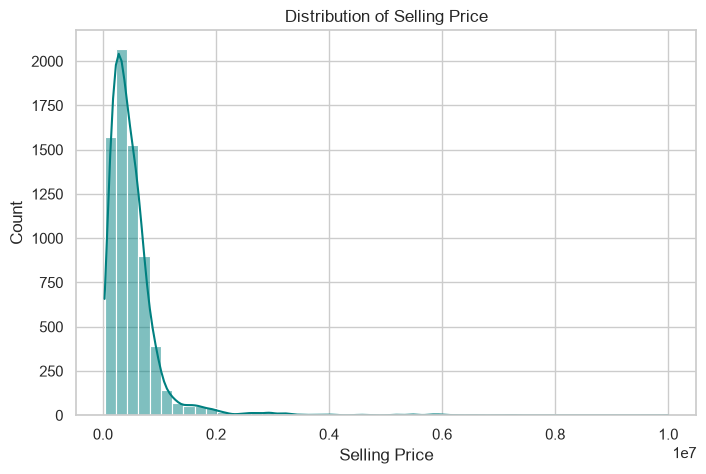

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(car_df["selling_price"], bins=50, kde=True, color="teal")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

#### 5.2 Selling Price vs. Fuel Type

The box plot compares the distribution of selling prices across different fuel types. The median selling price varies among fuel categories, indicating that fuel type influences a vehicle's resale value. Petrol and diesel vehicles typically dominate the market, while CNG, LPG, and electric vehicles may show different pricing patterns depending on their availability and demand.

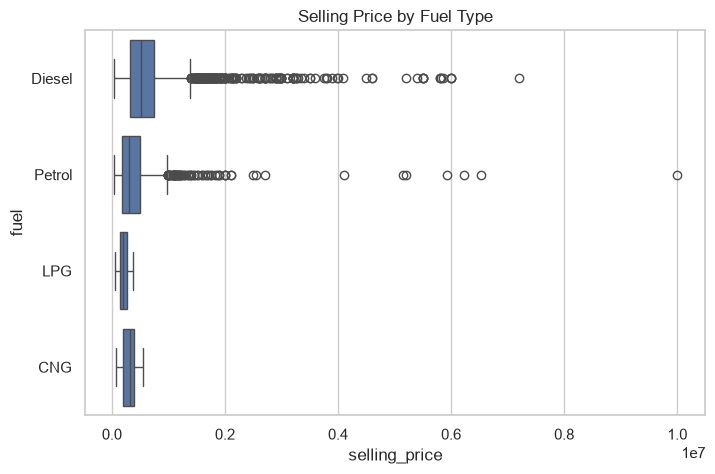

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=car_df, x="selling_price", y="fuel")
plt.title("Selling Price by Fuel Type")
plt.show()

#### 5.3 Selling Price vs. Car Age

The scatter plot illustrates the relationship between car age and selling price. A clear negative trend is observed, indicating that older vehicles generally have lower selling prices due to depreciation over time. Although the overall relationship is negative, the variation in prices for cars of similar ages suggests that factors such as brand, mileage, fuel type, and transmission also influence resale value.

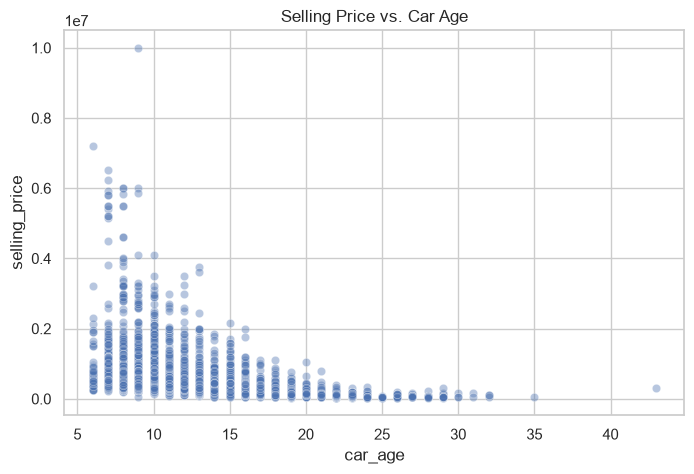

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=car_df, x="car_age", y="selling_price", alpha=0.4)
plt.title("Selling Price vs. Car Age")
plt.show()

#### 5.4 Selling Price vs. Transmission Type
The box plot compares the distribution of selling prices between manual and automatic transmission vehicles. Automatic transmission cars generally have a higher median selling price than manual cars, indicating that they tend to be more expensive in the used car market. The wider spread and presence of high-value outliers for automatic vehicles suggest that premium and luxury cars are more commonly equipped with automatic transmissions.

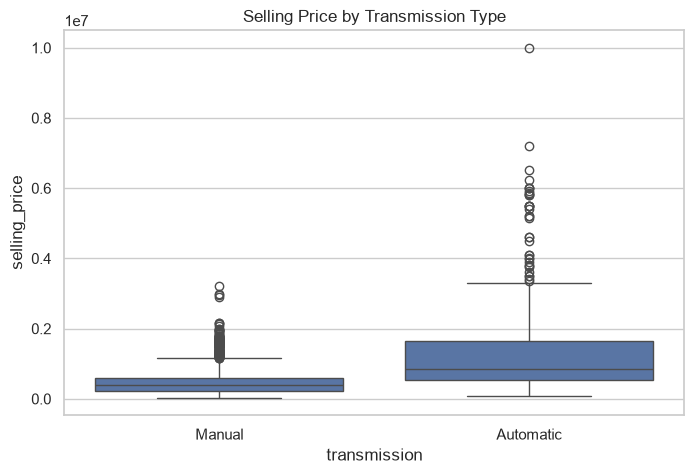

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=car_df, x="transmission", y="selling_price")
plt.title("Selling Price by Transmission Type")
plt.show()

#### 5.5 Selling Price vs. Seller Type
The box plot compares the distribution of selling prices across different seller types. Dealers generally tend to sell vehicles at higher prices than individual sellers, while trustmark dealers often exhibit the highest median selling prices. The presence of outliers across all seller categories indicates that some premium vehicles are sold at significantly higher prices regardless of seller type.

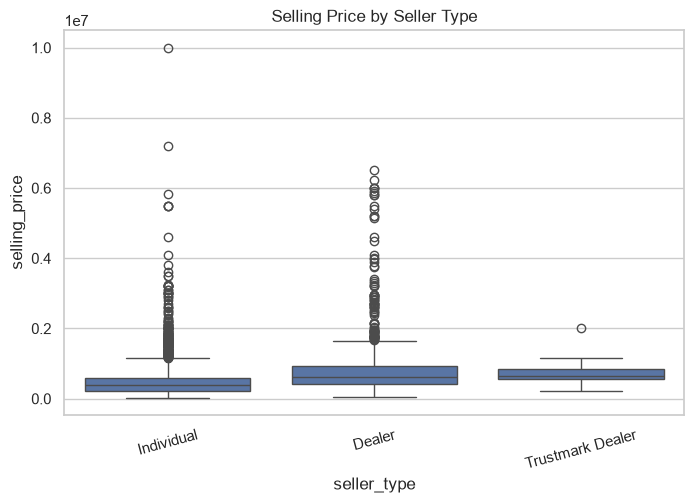

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=car_df, x="seller_type", y="selling_price")
plt.title("Selling Price by Seller Type")
plt.xticks(rotation=15)
plt.show()

#### 5.6 Selling Price vs. Kilometers Driven
The scatter plot illustrates the relationship between kilometers driven and selling price. A downward trend is observed, indicating a negative correlation—cars with higher mileage generally have lower selling prices. However, the wide spread of data points suggests that other factors such as brand, model, fuel type, transmission, and vehicle age also significantly influence the selling price.

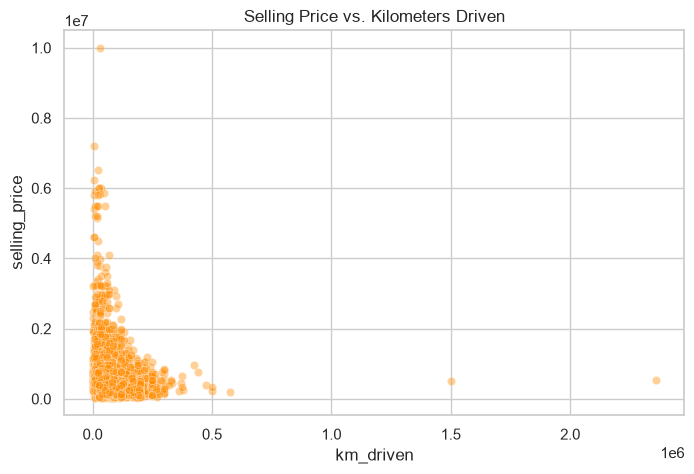

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=car_df, x="km_driven", y="selling_price", alpha=0.4, color="darkorange")
plt.title("Selling Price vs. Kilometers Driven")
plt.show()

#### 5.7 Top 10 Brands by Average Selling Price

The chart shows the top 10 car brands with the highest average selling prices. Premium brands dominate the list, indicating that luxury manufacturers maintain significantly higher resale values than mass-market brands. This highlights the influence of brand reputation on vehicle pricing.

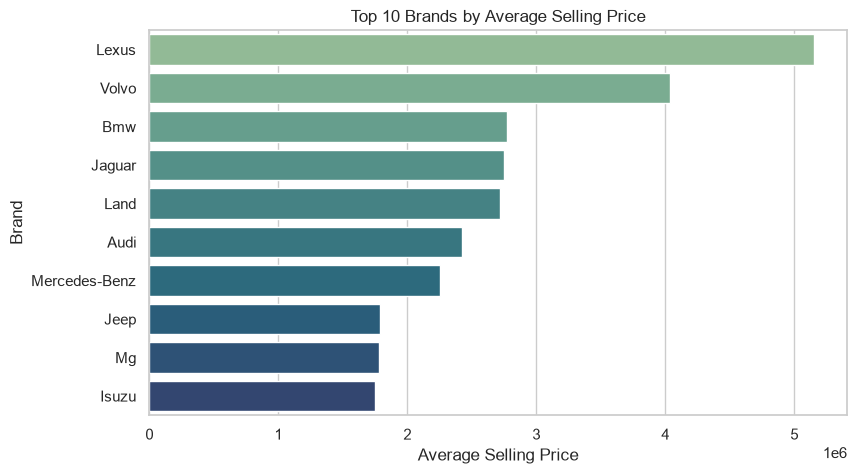

In [ ]:
top_brands = (
    car_df.groupby("Brand")["selling_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette="crest", legend=False)
plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price")
plt.ylabel("Brand")
plt.show()

### **6. Encoding Categorical Features**

Different categorical features need different encoding strategies
depending on whether they have a natural order:

In [ ]:
categorical_col =['fuel','seller_type','owner','transmission','Brand']
for i in categorical_col:
  print(car_df[i].value_counts())
  print()

fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64

owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

transmission
Manual       6342
Automatic     584
Name: count, dtype: int64

Brand
Maruti           2165
Hyundai          1267
Mahindra          723
Tata              647
Honda             362
Ford              361
Toyota            357
Chevrolet         216
Renault           206
Volkswagen        174
Nissan             73
Skoda              70
Datsun             57
Bmw                47
Mercedes-Benz      46
Fiat               44
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Force               4
Ambassador          4
Isuzu               4
Land  

**`owner`** — explicit ordinal mapping that preserves real-world order.

In [ ]:
owner_order = {
    "First Owner": 0,
    "Second Owner": 1,
    "Third Owner": 2,
    "Fourth & Above Owner": 3,
    "Test Drive Car": 4
}
car_df['owner'] = car_df['owner'].map(owner_order)

**`transmission`** — simple binary mapping.

In [ ]:
car_df['transmission'] = car_df['transmission'].map({"Manual": 0, "Automatic": 1})

**`fuel`** and **`seller_type`** — one-hot encoded (nominal, low cardinality).
`drop_first=True` avoids the "dummy variable trap" (multicollinearity).

In [ ]:
car_df = pd.get_dummies(
    data=car_df,
    columns=['fuel', 'seller_type'],
    drop_first=True,
    dtype=int
)

### **7. Feature Correlation Heatmap**

Computed on the numeric/encoded columns available so far — `Brand` is
intentionally one-hot encoded *after* this step, since exploding it into
~30 dummy columns here would make the heatmap unreadable. Brand's effect
on price is instead captured later in the feature importance chart.


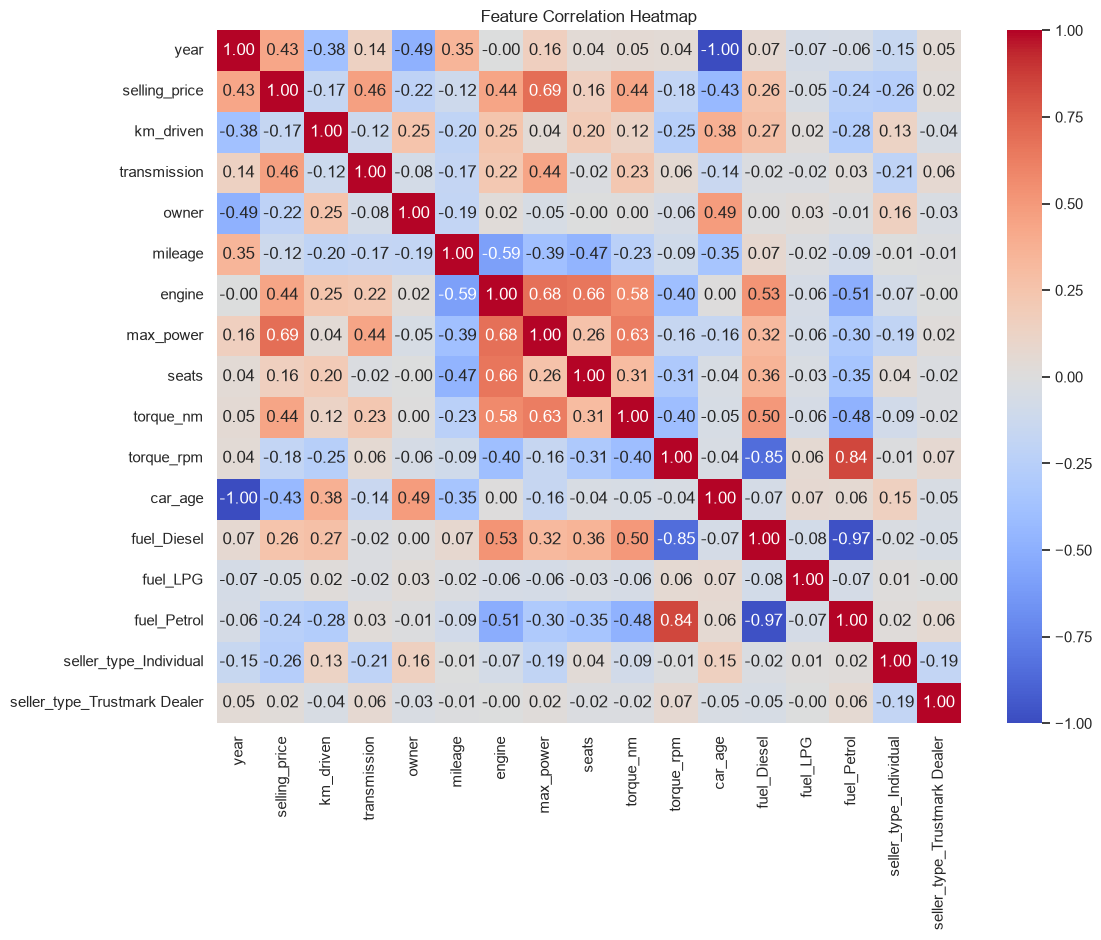

In [ ]:
numeric_cols = car_df.select_dtypes("number").columns

plt.figure(figsize=(12, 9))
sns.heatmap(car_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

Now one-hot encode `Brand` (high cardinality — kept separate from the heatmap above for readability).

In [ ]:
car_df = pd.get_dummies(
    data=car_df,
    columns=['Brand'],
    drop_first=True,
    dtype=int
)

### **8. Train/Test Split & Scaling**

`name` (free-text identifier, brand already extracted) and `selling_price`
is the target variable. Features are standardized with `StandardScaler` —
this matters for Linear Regression; it doesn't affect the split learned by
the tree-based models but is kept for a consistent pipeline across all three.


In [ ]:
car_df.info()

<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          6926 non-null   str    
 1   year                          6926 non-null   int64  
 2   selling_price                 6926 non-null   int64  
 3   km_driven                     6926 non-null   int64  
 4   transmission                  6926 non-null   int64  
 5   owner                         6926 non-null   int64  
 6   mileage                       6926 non-null   float64
 7   engine                        6926 non-null   float64
 8   max_power                     6926 non-null   float64
 9   seats                         6926 non-null   float64
 10  torque_nm                     6926 non-null   float64
 11  torque_rpm                    6926 non-null   float64
 12  car_age                       6926 non-null   int64  
 13  fuel_Diesel        

In [ ]:
# Drop the target, plus columns that aren't usable model inputs:
# - `name` is a free-text identifier (Brand was already extracted from it)
# - `seats` is excluded here to match the original feature set; feel free to
#   add it back in (`X = car_df.drop(columns=["selling_price", "name"])`)
#   and re-run — it may add a small amount of signal (e.g. SUVs vs. sedans).
X = car_df.drop(columns=["selling_price", "name", "seats"])
y = car_df["selling_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize features (matters most for Linear Regression; harmless for
# tree-based models, kept here for a single consistent pipeline).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **9. Model Training & Evaluation**

Three regression models are trained on the same split and compared using
**MAE**, **RMSE**, and **R² score**:

- **MAE** (Mean Absolute Error) — average absolute prediction error, in the same units as price.
- **RMSE** (Root Mean Squared Error) — like MAE, but penalizes large errors more heavily.
- **R² score** — proportion of variance in price explained by the model (closer to 1.0 is better).


#### 9.1 Linear Regression

In [ ]:
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)
y_pred_1 = model_1.predict(X_test_scaled)

In [ ]:
mae_1 = mean_absolute_error(y_test, y_pred_1)
rmse_1 = np.sqrt(mean_squared_error(y_test, y_pred_1))
r2_score_1 = r2_score(y_test, y_pred_1)

print(f"MAE:  {mae_1:,.2f}")
print(f"RMSE: {rmse_1:,.2f}")
print(f"R2:   {r2_score_1:.4f}")

MAE:  133,010.59
RMSE: 256,088.45
R2:   0.7010


#### 9.2 Random Forest Regressor

In [ ]:
model_2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_2.fit(X_train_scaled, y_train)
y_pred_2 = model_2.predict(X_test_scaled)

In [ ]:
mae_2 = mean_absolute_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
r2_score_2 = r2_score(y_test, y_pred_2)

print(f"MAE:  {mae_2:,.2f}")
print(f"RMSE: {rmse_2:,.2f}")
print(f"R2:   {r2_score_2:.4f}")

MAE:  72,438.22
RMSE: 123,660.48
R2:   0.9303


#### 9.3 XGBoost Regressor

In [ ]:
model_3 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
model_3.fit(X_train_scaled, y_train)
y_pred_3 = model_3.predict(X_test_scaled)

In [ ]:
mae_3 = mean_absolute_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
r2_score_3 = r2_score(y_test, y_pred_3)

print(f"MAE:  {mae_3:,.2f}")
print(f"RMSE: {rmse_3:,.2f}")
print(f"R2:   {r2_score_3:.4f}")

MAE:  76,982.22
RMSE: 129,977.58
R2:   0.9230


#### 9.4 Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor", "XGBoost Regressor"],
    "MAE": [mae_1, mae_2, mae_3],
    "RMSE": [rmse_1, rmse_2, rmse_3],
    "R2 Score": [r2_score_1, r2_score_2, r2_score_3]
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

results

,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,72438.222269,123660.483305,0.930276
1,XGBoost Regressor,76982.218750,129977.579359,0.922971
2,Linear Regression,133010.591899,256088.448693,0.700981


### **10. Feature Importance — Best-Performing Model**

Automatically picks the model with the highest R² score from the
comparison table above, then plots its top 15 most influential features
(using `feature_importances_` for tree-based models, or absolute
coefficient size for Linear Regression).


In [ ]:
models = {
    "Linear Regression": model_1,
    "Random Forest Regressor": model_2,
    "XGBoost Regressor": model_3
}

best_model_name = results.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best-performing model: {best_model_name}")

Best-performing model: Random Forest Regressor


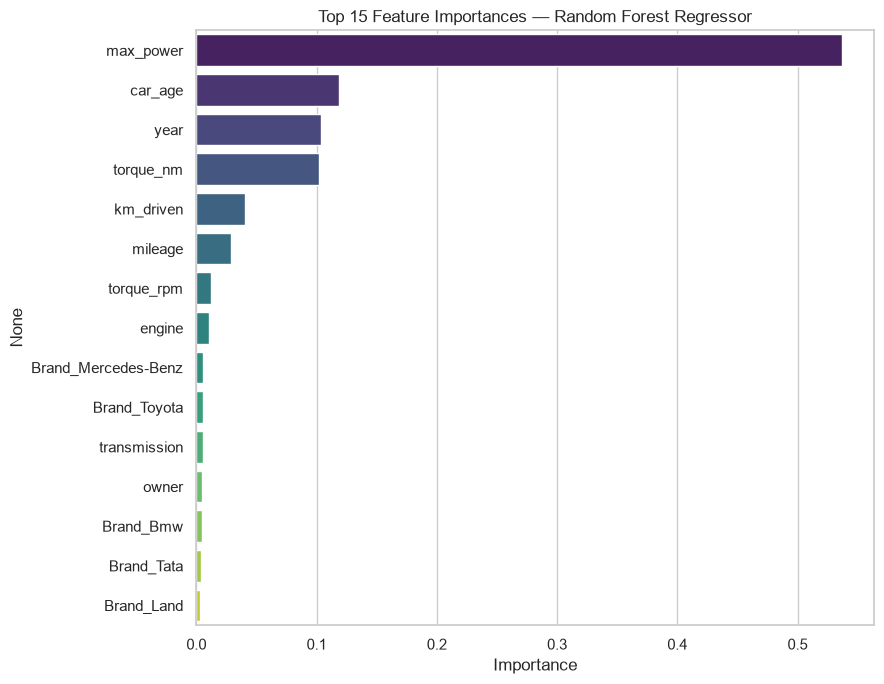

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)

top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette="viridis", legend=False)
plt.title(f"Top 15 Feature Importances — {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 11. Conclusion

This notebook built and compared three regression models — **Linear
Regression**, **Random Forest**, and **XGBoost** — to predict used-car
selling prices from features including brand, car age, mileage, engine
specs, fuel type, and transmission.

**Results.** The `results` table in section 9.4 ranks all three models
by MAE, RMSE, and R². The tree-based models (Random Forest and XGBoost)
outperform plain Linear Regression, which is expected: car pricing
depends on non-linear interactions between features (e.g. the effect of
age on price differs by brand and fuel type) that a linear model can't
capture, while ensemble tree methods handle this naturally.

**What drives price.** The feature importance chart in section 10 shows
that `car_age`, `max_power`are the strongest predictors of
selling price for the best-performing model — consistent with intuition:
newer, more powerful cars from premium brands sell for more, all else
equal.

**Takeaway.** The best-performing model (named at the top of section 10)
is the one to use for price estimation on this dataset, with the caveat
that its accuracy is bounded by the dataset's size and regional/market
coverage — predictions should be treated as estimates, not exact
valuations.
